In [1]:
import sys
sys.path.append('./')
sys.path.append('/Users/ASUS/Documents/GitHub/retrospective_t2e_analysis/retrospective_t2e/')

from gls import datasets

import pandas as pd
import numpy as np

def load_sprint_trial_data(outcome='EVENT_PRIMARY'):
  assert outcome in ['EVENT_PRIMARY', 'EVENT_PRIMARYORDEATH'], "outcome can only be one of 'EVENT_PRIMARY' or 'EVENT_PRIMARY'"
  feature_list = {
    # demographic data
    'baseline.sas7bdat' : ['AGE', 'FEMALE', 'RACE4', 'SMOKE_3CAT', 'BMI', 'INTENSIVE',
                          'RISK10YRS', 'INCLUSIONFRS', 'SBP', 'DBP', 'N_AGENTS', 'NOAGENTS',
                          'ASPIRIN', 'EGFR', 'SCREAT', 'SUB_CKD', 'SUB_CVD', 'SUB_CLINICALCVD',
                          'SUB_SUBCLINICALCVD', 'SUB_SENIOR', 'CHR', 'GLUR', 'HDL', 'TRR', 'UMALCR',
                          'STATIN', 'SBPTERTILE', 'RACE_BLACK']
  }
  outcomes, features = datasets._load_generic_biolincc_dataset('outcomes.sas7bdat', 
                                                                   'T_PRIMARY', 'EVENT_PRIMARY',
                                                                   features=feature_list, 
                                                                   id_col='MASKID',
                                                                   location='datasets/SPRINT_POP/Datasets/')

  # Convert Censoring Indicator to Binary
  # ie. 1 = Event, 0 = Censored
  outcomes.event = outcomes.event == 1.0 
  
  NaNindex = pd.isna(outcomes.time)
  outcomes = outcomes.loc[~NaNindex]
  features = features.loc[~NaNindex]

  return outcomes, features

In [2]:
import pandas as pd
import torch
from tqdm import tqdm 
from examples.cmhe_demo_utils import * 

c:\Users\ASUS\anaconda3\envs\Pandas\lib\site-packages\tqdm\auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Load the synthetic dataset
outcomes, features = load_sprint_trial_data()

# Let's take a look at take the dataset
features.head(5)

(9361, 28)


c:\Users\ASUS\Documents\GitHub\retrospective_t2e_analysis\retrospective_t2e\auton_survival\gls\datasets.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:, col] = df[col].values.astype(str)
C:\Users\ASUS\AppData\Local\Temp\ipykernel_26928\3981226480.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outcomes.event = outcomes.event == 1.0


,SUB_SUBCLINICALCVD,INCLUSIONFRS,SBP,INTENSIVE,AGE,EGFR,DBP,TRR,SMOKE_3CAT,N_AGENTS,...,CHR,SUB_CLINICALCVD,NOAGENTS,ASPIRIN,STATIN,GLUR,RACE4,SBPTERTILE,BMI,RISK10YRS
S00007,0.0,1.0,145.0,0.0,60.0,67.69,80.0,92.0,3.0,2.0,...,155.0,1.0,0.0,1.0,1.0,81.0,WHITE,3.0,33.115201,29.732061
S00010,0.0,1.0,138.0,0.0,75.0,60.64,71.0,188.0,2.0,1.0,...,243.0,0.0,0.0,1.0,1.0,107.0,WHITE,2.0,28.842380,29.677619
S00022,0.0,0.0,144.0,1.0,56.0,85.09,84.0,183.0,1.0,3.0,...,232.0,0.0,0.0,0.0,1.0,95.0,HISPANIC,2.0,24.888358,9.597287
S00038,0.0,1.0,143.0,1.0,62.0,68.44,92.0,125.0,2.0,2.0,...,180.0,0.0,0.0,0.0,0.0,116.0,WHITE,2.0,33.643060,17.443819
S00045,0.0,0.0,123.0,0.0,75.0,71.94,68.0,109.0,1.0,2.0,...,234.0,0.0,0.0,0.0,0.0,93.0,WHITE,1.0,29.337871,8.627849


In [4]:
interventions = features['INTENSIVE']
interventions

S00007    0.0
S00010    0.0
S00022    1.0
S00038    1.0
S00045    0.0
         ... 
S99969    0.0
S99974    0.0
S99983    0.0
S99992    1.0
S99997    1.0
Name: INTENSIVE, Length: 9361, dtype: float64

In [5]:
from preprocessing import Preprocessor

cat_feats = ['RACE4', 'SMOKE_3CAT', 'FEMALE', 'INCLUSIONFRS', 'NOAGENTS', 'ASPIRIN',
            'SUB_CKD', 'RACE_BLACK', 'SUB_CVD', 'SUB_CLINICALCVD', 'SUB_SUBCLINICALCVD',
            'SUB_SENIOR', 'SBPTERTILE', 'STATIN']
num_feats = ['AGE', 'BMI', 'RISK10YRS', 'SBP', 'DBP', 'N_AGENTS', 'EGFR', 'SCREAT',
            'CHR', 'GLUR', 'HDL', 'TRR', 'UMALCR']

features = Preprocessor().fit_transform(features[cat_feats+num_feats], cat_feats=cat_feats, num_feats=num_feats)

In [6]:
features.head(5)

,AGE,BMI,RISK10YRS,SBP,DBP,N_AGENTS,EGFR,SCREAT,CHR,GLUR,...,ASPIRIN_1.0,SUB_CKD_1.0,RACE_BLACK_1.0,SUB_CVD_1.0,SUB_CLINICALCVD_1.0,SUB_SUBCLINICALCVD_1.0,SUB_SENIOR_1.0,SBPTERTILE_2.0,SBPTERTILE_3.0,STATIN_1.0
S00007,-0.840770,0.567923,0.891838,0.342168,0.156733,0.159574,-0.197156,0.104317,-0.854735,-1.317899,...,1,0,0,1,1,0,0,0,1,1
S00010,0.752309,-0.175767,0.886804,-0.107192,-0.596824,-0.803528,-0.540183,0.281514,1.287283,0.605608,...,1,0,0,0,0,0,1,1,0,1
S00022,-1.265591,-0.863970,-0.970130,0.277974,0.491647,1.122675,0.649462,-1.076998,1.019530,-0.282164,...,0,0,0,0,0,0,0,1,0,1
S00038,-0.628359,0.659798,-0.244520,0.213780,1.161475,0.159574,-0.160664,0.045251,-0.246207,1.271438,...,0,0,0,0,0,0,0,1,0,0
S00045,0.752309,-0.089526,-1.059779,-1.070106,-0.848010,0.159574,0.009633,-0.870268,1.068213,-0.430126,...,0,0,0,0,0,0,1,0,0,0


In [7]:
# Hyper-parameters
random_seed = 0
test_size = 0.4

# Split the synthetic data into training and testing data
import numpy as np

np.random.seed(random_seed)
n = features.shape[0] 

test_idx = np.zeros(n).astype('bool')
test_idx[np.random.randint(n, size=int(n*test_size))] = True 

features_tr = features.iloc[~test_idx] 
outcomes_tr = outcomes.iloc[~test_idx]
interventions_tr = interventions[~test_idx]
print(f'Number of training data points: {len(features_tr)}')

features_te = features.iloc[test_idx] 
outcomes_te = outcomes.iloc[test_idx]
interventions_te = interventions[test_idx]
print(f'Number of test data points: {len(features_te)}')

x_tr = features_tr.values.astype('float32')
t_tr = outcomes_tr['time'].values.astype('float32')
e_tr = outcomes_tr['event'].values.astype('float32')
a_tr = interventions_tr.values.astype('float32')

x_te = features_te.values.astype('float32')
t_te = outcomes_te['time'].values.astype('float32')
e_te = outcomes_te['event'].values.astype('float32')
a_te = interventions_te.values.astype('float32')

print('Training Data Statistics:')
print(f'Shape of covariates: {x_tr.shape} | times: {t_tr.shape} | events: {e_tr.shape} | interventions: {a_tr.shape}')

Number of training data points: 6271
Number of test data points: 3090
Training Data Statistics:
Shape of covariates: (6271, 32) | times: (6271,) | events: (6271,) | interventions: (6271,)


In [8]:
# Hyper-parameters to train model
k = 1 # number of underlying base survival phenotypes
g = 2 # number of underlying treatment effect phenotypes.
layers = [] # number of neurons in each hidden layer.

random_seed = 3
iters = 100 # number of training epochs
learning_rate = 0.001
batch_size = 128 
vsize = 0.15 # size of the validation split
patience = 3
optimizer = "Adam"

In [21]:
from models.cmhe import DeepCoxMixturesHeterogenousEffects

torch.manual_seed(random_seed)
np.random.seed(random_seed)

# Instantiate the CMHE model
model = DeepCoxMixturesHeterogenousEffects(random_seed=10, k=k, g=g, layers=layers)

model = model.fit(x_tr, t_tr, e_tr, a_tr, vsize=vsize, val_data=None, iters=iters, 
                  learning_rate=learning_rate, batch_size=batch_size, 
                  optimizer=optimizer, patience=patience)

100%|██████████| 100/100 [00:37<00:00,  2.66it/s]


In [22]:
zeta_probs_train = model.predict_latent_phi(x_tr)
zeta_train =  np.argmax(zeta_probs_train, axis=1)
zeta_train

array([1, 0, 1, ..., 0, 1, 1], dtype=int64)

In [23]:
idx_list_0 = np.where(zeta_train == 0)

In [24]:
idx_list_1 = np.where(zeta_train == 1)

In [25]:
zeta_train.mean()

0.7735608355924095

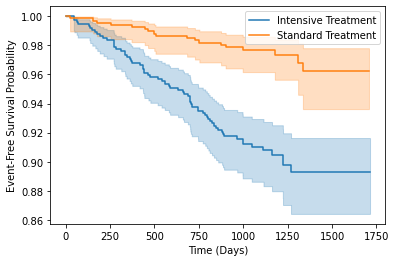

In [26]:
from auton_survival import reporting
import matplotlib.pyplot as plt

# Estimate the probability of event-free survival for phenotypes using the Kaplan Meier estimator.
ax = reporting.plot_kaplanmeier(outcomes_tr.iloc[idx_list_0], interventions_tr.iloc[idx_list_0])
h, l = ax.get_legend_handles_labels()
plt.xlabel('Time (Days)')
plt.ylabel('Event-Free Survival Probability')
plt.legend([h[0], h[1]], ['Intensive Treatment', 'Standard Treatment'], loc="upper right")
plt.show()

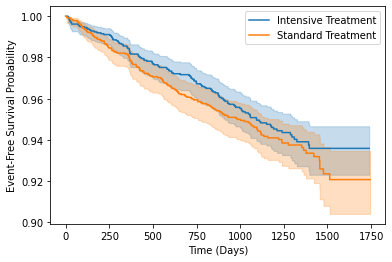

In [27]:
# Estimate the probability of event-free survival for phenotypes using the Kaplan Meier estimator.
ax2 = reporting.plot_kaplanmeier(outcomes_tr.iloc[idx_list_1], interventions_tr.iloc[idx_list_1])
h, l = ax2.get_legend_handles_labels()
plt.xlabel('Time (Days)')
plt.ylabel('Event-Free Survival Probability')
plt.legend([h[0], h[1]], ['Intensive Treatment', 'Standard Treatment'], loc="upper right")
plt.show()

In [28]:
zeta_probs_test = model.predict_latent_phi(x_te)
zeta_test =  np.argmax(zeta_probs_test, axis=1)
zeta_test

array([1, 1, 1, ..., 0, 1, 1], dtype=int64)

In [29]:
zeta_test.mean()

0.7763754045307444

In [30]:
idx_list_0te = np.where(zeta_test == 0)
idx_list_1te = np.where(zeta_test == 1)

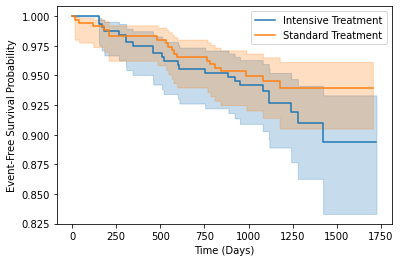

In [31]:
# Estimate the probability of event-free survival for phenotypes using the Kaplan Meier estimator.
ax3 = reporting.plot_kaplanmeier(outcomes_te.iloc[idx_list_0te], interventions_te.iloc[idx_list_0te])
h, l = ax3.get_legend_handles_labels()
plt.xlabel('Time (Days)')
plt.ylabel('Event-Free Survival Probability')
plt.legend([h[0], h[1]], ['Intensive Treatment', 'Standard Treatment'], loc="upper right")
plt.show()

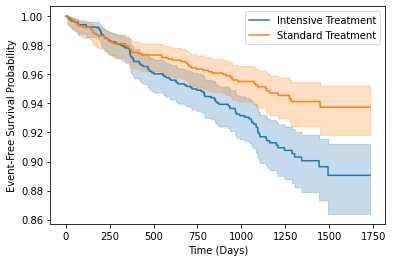

In [32]:
# Estimate the probability of event-free survival for phenotypes using the Kaplan Meier estimator.
ax4 = reporting.plot_kaplanmeier(outcomes_te.iloc[idx_list_1te], interventions_te.iloc[idx_list_1te])
h, l = ax4.get_legend_handles_labels()
plt.xlabel('Time (Days)')
plt.ylabel('Event-Free Survival Probability')
plt.legend([h[0], h[1]], ['Intensive Treatment', 'Standard Treatment'], loc="upper right")
plt.show()